In [ ]:
# Random forest on wine quality dataset

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


In [4]:
# import csv file
data = pd.read_csv("WineQT.csv", sep=",")

In [5]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
# define X and Y variables
X = data.drop("quality", axis=1)
y = data["quality"]

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# fit a decision tree model
dt_model = DecisionTreeClassifier(random_state=42)  # random state for reproducibility
dt_model.fit(X_train, y_train)
y_train_pred = dt_model.predict(X_train)
print("Decision Tree Accuracy on train:", accuracy_score(y_train, y_train_pred))
y_dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_dt_pred))
print(confusion_matrix(y_test, y_dt_pred))

Decision Tree Accuracy on train: 1.0
Decision Tree Accuracy: 0.5633187772925764
[[ 0  0  0  0  0  0]
 [ 0  2  2  1  1  0]
 [ 0  3 63 27  3  0]
 [ 2  1 32 45 17  2]
 [ 0  0  0  8 18  0]
 [ 0  0  0  0  1  1]]


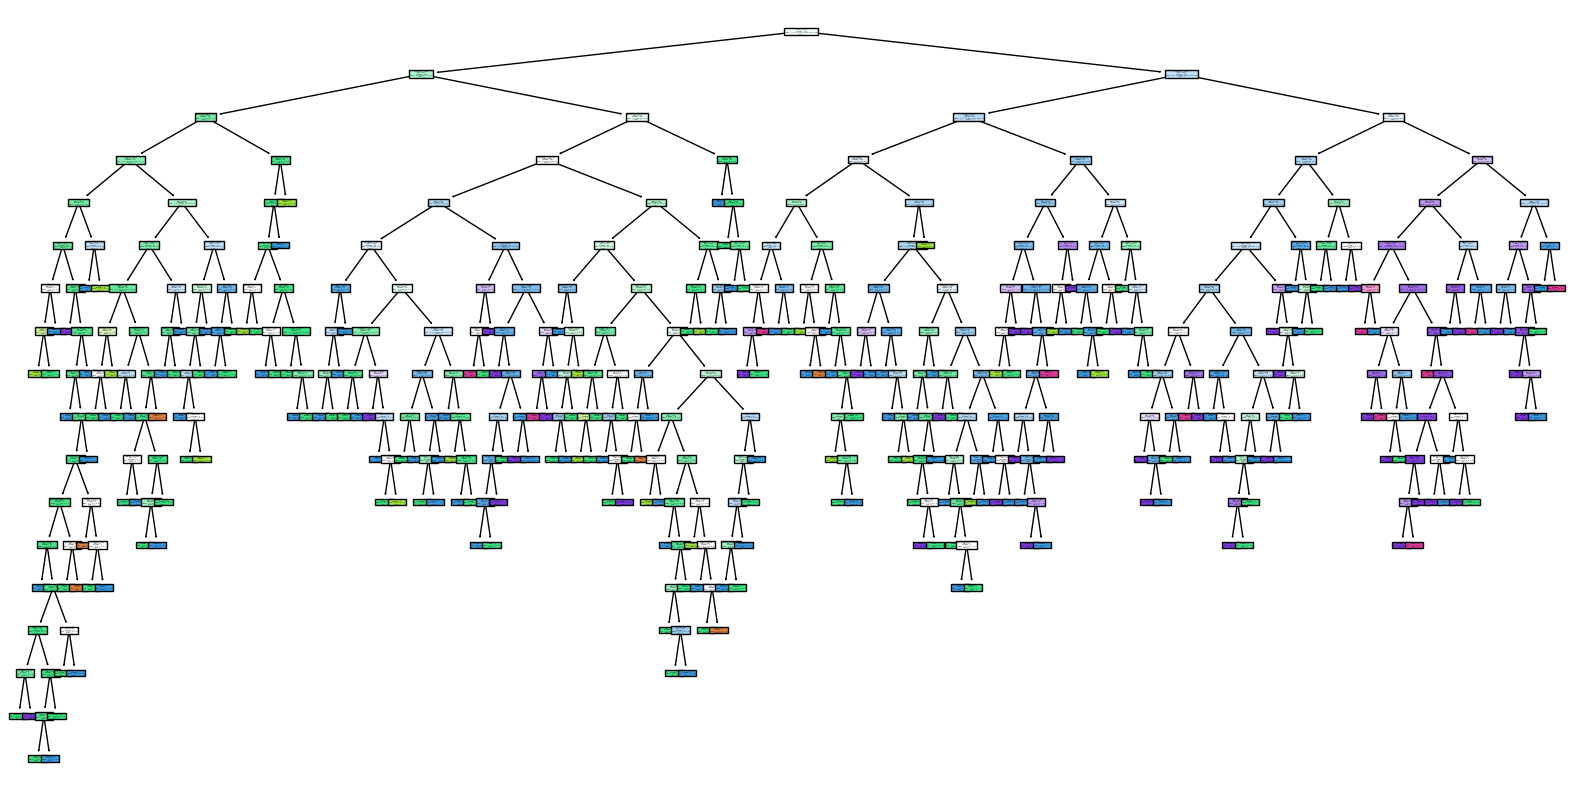

In [8]:
# Visualize the decision tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=data.columns[:-1], class_names=data["quality"].unique().astype(str))
plt.show()


In [31]:
# fitting a Random Forest model and comparing results with decision tree.
rf_model = RandomForestClassifier(random_state=42)  # random state for reproducibility

# accuracy of the random forest model
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))

Random Forest Accuracy: 0.6812227074235808
[[ 0  3  3  0  0]
 [ 0 72 24  0  0]
 [ 0 24 69  5  1]
 [ 0  0 11 15  0]
 [ 0  0  2  0  0]]


In [ ]:
# improve the accuracy of the random forest model by tuning hyperparameters
# rf_model = RandomForestClassifier(random_state=42,n_estimators=70, max_depth=10)  # random state for reproducibility
rf_model = RandomForestClassifier(random_state=42,n_estimators=100, max_depth=15 , max_features='log2')  # random state for reproducibility
# max_features is the number of features to consider when looking for the best split. You can change it to 'sqrt' or 'log2' and see how it affects the results.

rf_model.fit(X_train, y_train) 
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy after tuning:", accuracy_score(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))

Random Forest Accuracy after tuning: 0.6899563318777293
[[ 0  3  3  0  0]
 [ 0 73 23  0  0]
 [ 0 24 71  3  1]
 [ 0  0 12 14  0]
 [ 0  0  2  0  0]]


In [36]:
# finding the optimal hyperparameters using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 70, 100, 200],
    'max_depth': [None, 10, 15, 20]
   # 'min_samples_split': [2, 5, 7, 10],
   # 'min_samples_leaf': [1, 2, 3, 4]
}
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_
y_rf_pred = best_rf_model.predict(X_test)
print("Random Forest Accuracy after GridSearchCV:", accuracy_score(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 200}
Random Forest Accuracy after GridSearchCV: 0.6855895196506551
[[ 0  3  3  0  0]
 [ 0 73 22  1  0]
 [ 0 25 68  6  0]
 [ 0  0 10 16  0]
 [ 0  0  2  0  0]]
